In [9]:
#求导
from sympy import *

n = symbols('n')
y = 1250*(2-exp(-(n-5000)**2))

func1 = diff(y,n) # 求导数，对y求n的导数
func2 = diff(y, n, 2)#二阶导
func1

-1250*(10000 - 2*n)*exp(-(n - 5000)**2)

In [10]:
#求驻点
stag = solve(diff(y,n),n)
print("该函数驻点为",stag) # 计算驻点
#驻点的二阶导数值
func2.evalf(subs = {n:5000})
#对应函数的极小值
y.evalf(subs = {n:5000})

该函数驻点为 [5000]


1250.00000000000

<strong> 定义1:[Hesse 矩阵] </strong> 
设 $f:\mathbf{R}^n\to R$ 是 $n$ 元函数$,$ $x_i,i=1,2,\cdots,n$ 是变量.
	
记 $f$ 对变量 $x_i$ 方向的偏导数为 $f'_i,$ 称所有偏导数组成的列向量 $[f_1',f_2',\cdots,f_n']^T := \nabla f,$ 为函数 $f$ 的全导数$,$ 亦称**梯度**.
	
记偏导数 $f_i'$ 对变量 $x_j$ 方向的二阶偏导数为 $f''_{ij}$ 称 $n\times n$ 方阵$$\begin{bmatrix}
		f''_{11}&f''_{12}&\cdots & f''_{1n}\\
		f''_{21}&f''_{22}&\cdots & f''_{1n}\\
		\vdots&\vdots&\ddots &\vdots\\
		f''_{n1}&f''_{n2}&\cdots & f''_{nn}\\
	\end{bmatrix} := \nabla^2 f,$$ 
为函数 $f$ 的<strong> Hesse 矩阵</strong>.
</div>

梯度下降法：通过迭代的方式找到一组梯度递减的点，当点的梯度下降的足够接近0时便可以认为该点是极值的候选之一。

In [11]:
#求多元函数极值
import scipy.optimize as opt
from scipy import fmin
import numpy as np
def func0(cost, x, a):#成本函数
    return cost*x*(2 - exp(-(x - a)**2))

#x[0]，x[1]，x[2]分别是三个微分变量
func = lambda x: (2000*x[0] + 3000*x[1] + 4500*x[2]) / (func0(750, x[0], 6000) + func0(1250, x[1], 5000) + func0(2000, x[2], 3000)) - 1 
bnds = ((1, 10000), (1, 10000), (1, 10000))#范围
res = opt.minimize(fun=func, x0=np.array([2, 1, 1]), bounds=bnds)
res

      fun: 0.126003411879638
 hess_inv: <3x3 LbfgsInvHessProduct with dtype=float64>
      jac: array([ 6.24122979e-04,  3.71236377e-04, -8.08242869e-06])
  message: 'CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL'
     nfev: 64
      nit: 15
     njev: 16
   status: 0
  success: True
        x: array([  1.        ,   1.        , 123.57496521])

插值：解决数据的补充、还原等问题    
以三次样条插值为例，最实用的性质是摆动极小。  
</strong> 
定义：设 $(x_i,y_i),i=1,2,\cdots,n$ 是 $\mathbf{R}^2$ 上的 $n$ 个点$,$ 其三次样条插值函数为
 	$$f_i(t)=s_{i,0}+s_{i,1}t+s_{i,2}t^2+s_{i,3}t^3,i=1,2,\cdots, n-1,$$
 	满足   
$\begin{aligned} f_{i}\left(x_{i}\right) &=y_{i}, i=1,2, \cdots, n-1, f_{n-1}\left(x_{n}\right)=y_{n} \\ f_{i}\left(x_{i+1}\right) &=y_{i+1}\left(x_{i+1}\right), i=1,2, \cdots, n-2 \\ f_{i}^{\prime}\left(x_{i+1}\right) &=y_{i+1}^{\prime}\left(x_{i+1}\right), i=1,2, \cdots, n-2 \\ f_{i}^{\prime \prime}\left(x_{i+1}\right) &=y_{i+1}^{\prime \prime}\left(x_{i+1}\right), i=1,2, \cdots, n-2 . \end{aligned}$

积分解决工程问题：    
通过微元法将连续变化的函数（例如变力做功、连续型随机变量期望值等等连续物理量）先微分再积分得到相关量


In [12]:
#定积分的python代码
from scipy import integrate # 已知函数表达式积分
from scipy import pi
def f(h):
    '''
    定义函数表达式.
    '''
    return 88.2 * pi * (5 - h)
v, err = integrate.quad(f, 0, 5) # 被积函数与积分区间
v

3463.605900582747

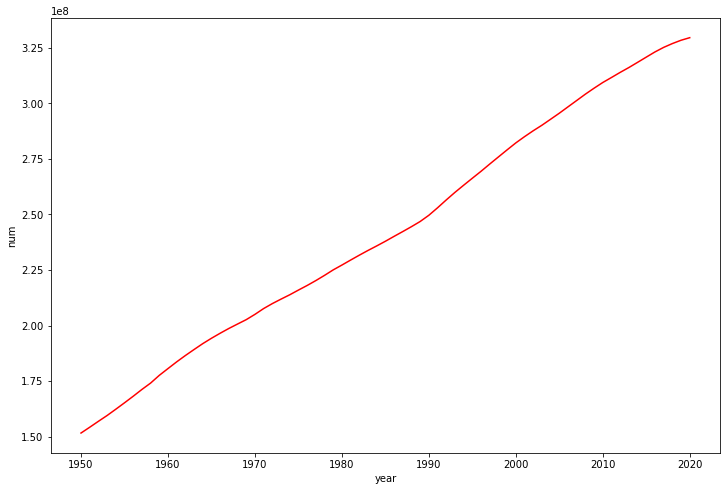

In [13]:
#作业部分
'''
题目：搜集1950-2020之间的美国人口数据，猜测买组的函数关系式，并综合数据预测美国2030年的人口数
'''
#导入数据
import pandas as pd
import openpyxl
import matplotlib.pyplot as plt
def data_in(file_path):  # 从指定路径读取文件并返回
    wb = openpyxl.load_workbook(file_path)
    sheets = wb.sheetnames
    ws = wb.active
    x, y = [], []
    for line in ws:
        x.append(line[0].value)
        y.append(line[1].value)
    return (x,y)
year, num = data_in('C:/Users/22454/Desktop/USA_PeopleNum.xlsx')
fig, ax = plt.subplots(1, figsize=(12, 8))
ax.plot(year, num, color='red')
ax.set(xlabel='year', ylabel='num')
plt.show()

[array([3174271.42857143*x - 571271.428571425*(x - 1950)**3 - 6038145285.71429],
      dtype=object), array([921185.714285731*x - 571271.428571425*(1952 - x)**3 + 1174542.85714285*(x - 1951)**3 - 1642375057.14294],
      dtype=object), array([5591357.1428571*x + 1174542.85714285*(1953 - x)**3 - 1805814.28571428*(x - 1952)**3 - 10758549685.7142],
      dtype=object), array([-1524399.99999997*x - 1805814.28571428*(1954 - x)**3 + 2544585.7142857*(x - 1953)**3 + 3138524014.28571],
      dtype=object), array([8682942.85714284*x + 2544585.7142857*(1955 - x)**3 - 3254357.14285713*(x - 1954)**3 - 16806623928.5714],
      dtype=object), array([-4303485.71428567*x - 3254357.14285713*(1956 - x)**3 + 3995128.57142855*(x - 1955)**3 + 8581843928.57129],
      dtype=object), array([11730528.5714285*x + 3995128.57142855*(1957 - x)**3 - 4682399.99999998*(x - 1956)**3 - 22780688014.2856],
      dtype=object), array([-7092071.42857137*x - 4682399.99999998*(1958 - x)**3 + 5276671.4285714*(x - 1957)**3 + 1

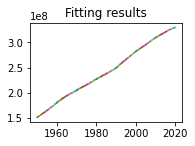

In [20]:
'''
看这个图像，肯定不是线性。
另一方面，图像走势比较光滑，至少没有突变，因此认为是一阶可导，如果仅拟合二次函数，精度肯定还是不够的，因此选择采用三次样条插值
'''
#这一部分是采用三次样条插值拟合数据，分成了70个区间

#两侧的导数设为0
import matplotlib.pyplot as plt
import pandas as pd
import openpyxl
import numpy as np
from sympy import *
class CubicSpline:
    def __init__(self, interval, n):
        self.interval = interval  # 插值区间
        self.num = n  # 区间数
        self.h = 70 / n  # 插值间隔

    def create_point(self):  # 给出插值点
        x = year
        y = num
        return np.stack((x, y), axis=1)

    def cal_mu_and_lamda(self):  # 计算出lamda和mu
        return 1 # 所有的h均相通

    def end_M(self):
        # M0 = self.cal_diff2(self.interval[0])
        # Mn = self.cal_diff2(self.interval[1])
        # return M0, Mn #第二类补充条件
        return 0, 0  # 自然边界条件

    def cal_d(self):  # 计算结果向量
        points = self.create_point()
        d = np.zeros((self.num - 1, 1))
        # 计算g1至gn-1
        for i in range(1, self.num):
            d[i - 1] = 6 / (2 * self.h * self.h) * (points[i + 1, 1] + points[i - 1, 1] - 2 * points[i, 1])
        # 已知m0和m1，所以修正方程组
        M0, Mn = self.end_M()
        # print(self.cal_mu_and_lamda()*M0)
        d[0] = d[0] - self.cal_mu_and_lamda() * M0
        d[-1] = d[-1] - self.cal_mu_and_lamda() * Mn
        return d

    def cal_M_coff(self):  # 计算系数矩阵
        M_coff = np.zeros((self.num - 1, self.num - 1))
        mu = lamda = self.cal_mu_and_lamda()
        for i in range(1, self.num - 2):
            # M_coff[i, i-1 ,i+2] = [mu, 2, lamda]
            M_coff[i, i - 1] = self.cal_mu_and_lamda()
            M_coff[i, i + 1] = self.cal_mu_and_lamda()
            M_coff[i, i] = 2
        M_coff[0, 0] = M_coff[-1, -1] = 2
        M_coff[0, 1] = M_coff[-1, -2] = mu
        return M_coff

    def cal_M(self):  #
        M_coff = self.cal_M_coff()
        d = self.cal_d()
        M = np.linalg.solve(M_coff, d)
        # print(M)
        M0 = self.end_M()[0]
        Mn = self.end_M()[1]
        M = np.vstack((M0, M))
        M = np.vstack((M, Mn))
        return M

    def cal_diff2_sx(self):
        sx0 = self.end_M()[0]
        sxn = self.end_M()[1]
        x = Symbol('x')
        diff2_sx = [None] * self.num
        M = self.cal_M()  # 0-num-2 对应 M1-Mnum-1
        points = self.create_point()
        for i in range(0, self.num):
            diff2_sx[i] = M[i, 0] * (points[i, 0] - x) / (self.h) + M[i + 1, 0] * (x - points[i - 1, 0]) / (self.h)
        # print(diff2_sx)
        return diff2_sx

    def cal_sx(self):
        x = Symbol('x')
        sx = []
        M = self.cal_M()
        points = self.create_point()
        for i in range(1, len(points)-3):  # 1-num-1
            Ai = 1 / self.h * (points[i - 1, 1] - 1 / 6 * M[i - 1] * pow(self.h, 2))
            Bi = 1 / self.h * (points[i, 1] - 1 / 6 * M[i] * pow(self.h, 2))
            sxi = (M[i - 1] * pow(points[i, 0] - x, 3) + M[i] * pow(x - points[i - 1, 0], 3)) / (6 * self.h) + Ai * (
                        points[i, 0] - x) + Bi * (x - points[i - 1, 0])
            sx.append(sxi)
        print(sx)
        return sx

    def show_result(self):
        sx = self.cal_sx()
        points = self.create_point()
        draw_y = np.zeros((500,))
        for i in range(len(sx)):
            draw_x = np.linspace(points[i, 0], points[i + 1, 0], 500)
            for j in range(len(draw_x)):
                draw_y[j] = sx[i][0].subs('x', draw_x[j])
            ax = plt.subplot(224)
            ax.set_title("Fitting results")
            plt.plot(draw_x, draw_y)
        
        plt.show()


test3 = CubicSpline([1950, 2020], 70)
test3.show_result()
plt.show()

In [23]:
#选取2018-2019那个区间的式子，因为其中融入了2018和2020的趋势（斜率、曲率）
#直接把2030代入那个式子
x = 2030
915685.714285731*x - 440542.857142862*(2019 - x)**3 + 135771.428571431*(x - 2018)**3 - 1520575228.57153

1159242342.857086

小结：
肉眼可见的不太准，但是最近被期末考试缠着，也实在没经历更新了（有空一定）
但是应该会比线性模型准一点，我认为线性模型中包含的是1950-2020的大趋势，太粗糙了
不准的原因也是模型并不贴合数据，他贴合的只是2018-2019区间，并包含了2019跨年2020的趋势。目前想到最好的办法机器学习的玩意去预测。分出测试集，并不断用预测值减去测试集中的真实值，不断迭代使模型更贴合实际，这样看起来才应该是个最优解
因此当看到题目第一眼，就有点想用个MLP解决问题哈哈哈哈

展望：
考虑分出15%的数据作为测试集，然后不断调整函数的参数，使最终MSE最小，那就是个好模型。

